# Tumor growth-rate tracking across a therapy window (two temporal datapoints)

Longitudinal analysis of a single patient from the NCI Imaging Data Commons **`anti_pd_1_lung`**
collection (anti-PD-1 immunotherapy non-small cell lung cancer (NSCLC) cohort). Data extraction, visualization, and analysis practice. (And just curious if this patient reached the therapeutic goal of the immunotherapy)

**Patient:** `PD-1-Lung-00001` — two chest-CT timepoints, at day 0 and at day 57, each shipping a shared AI nodule
(tumor) segmentation for all timepoints, so **gross tumor volume (GTV)** comparison is available.

**Pipeline**
*Clinical background about anti-PD-1 immunotherapy in lung cancer & setting therapeutic goal (GTV reduction %) from the literature*
1. Configure patient
2. Query the CT timeline + nodule (tumor) segmentations per timepoint
3. Download all CT scans for the patient + the nodule SEG
4. Read per-scan acquisition date/time + therapy-window metadata
5. Decode the nodule SEG and translate into GTV (mL) at each timepoint
6. Growth metrics: interval, absolute/relative change, specific growth rate, volume doubling time (not so useful for this case of two temporal datapoints, but for future usage)
7. Visualize analytics
8. Interpretation and commentary on the recommended monitoring (doctors please tell me if I am wrong, I want to learn)
9. Planned next task

> Methodology note: dates in IDC/TCIA are anonymized per-patient, but they inform the interval between two timepoints. To keep model variability from masquerading as biological change, I
> use the *same* AI segmentation method at every timepoint. (See 9. Planned next study for expert human vs AI segmentation model performance comparison)

## Clinical background: anti-PD-1 immunotherapy in lung cancer

### Mechanism of action
PD-1 (programmed cell death protein 1) is an inhibitory receptor on activated T cells. When it binds
its ligand **PD-L1**, expressed by many tumor cells and immune cells, it delivers a "brake" signal that
drives **CD8+ T-cell exhaustion** and blunts the anti-tumor immune response. **Anti-PD-1 antibodies**
(e.g., nivolumab, pembrolizumab) block the PD-1/PD-L1 axis, *going slow on the brakes* and reinvigorating tumor-reactive CD8+ T cells so they can kill tumor cells [1, 2]. Recent single-cell work
refines this picture: durable responses also depend on mobilizing T-cell states from **outside** the
tumor microenvironment, not only reinvigorating those already inside it [1].

### Why anti-PD-1 for lung cancer
Non-small cell lung cancer (NSCLC) is often **immunogenic** — high tumor mutational/neoantigen burden
(especially smoking-related) and frequent PD-L1 expression — making PD-L1 expression as a checkpoint
blockade. In first-line advanced NSCLC with high PD-L1 (tumor proportion score ≥50%), pembrolizumab
beat the chemotherapy(!) on progression-free survival (10.3 vs 6.0 months) and overall survival
(HR 0.60), with fewer adverse events (KEYNOTE-024) [3]. The benefit extended to PD-L1 ≥1%
(OS HR 0.81; KEYNOTE-042), very impressive [4]. These results made anti-PD-1 a standard of care for advanced NSCLC that
lacks sensitizing *EGFR*/*ALK* alterations.

### Which lung cancer stage is appropriate
Anti-PD-1 therapy now spans the disease spectrum:
- **Advanced / metastatic (stage IV) or locally advanced unresectable NSCLC** — first-line, as
  monotherapy when PD-L1 is high (≥50%) [3], extendable to PD-L1 ≥1% [4], or combined with chemotherapy
  regardless of PD-L1; patients with *EGFR*/*ALK* drivers are generally excluded [3, 4].
- **Resectable early-stage disease (stage I–IIIA)** — as **neoadjuvant** (pre-surgical) therapy: a
  pilot of neoadjuvant nivolumab achieved a major pathological response in 45% of resected
  tumors [5], and neoadjuvant PD-1/PD-L1 + chemotherapy is now established; adding adjuvant
  (post-surgical) PD-1 blockade on top of neoadjuvant not shown to be effective in improving survival rate [6].

### This patient's disease stage
The patient analyzed in this notebook (`anti_pd_1_lung` cohort) is in the **advanced/metastatic**
setting, imaged before and during anti-PD-1 treatment.

### General immunotherapy therapeutic goal
Treatment response is judged by **change in tumor burden** using **RECIST 1.1** [7], measured on the
sum of the longest diameters of target lesions:
- **Complete response (CR):** disappearance of all target lesions.
- **Partial response (PR):** **≥30% decrease** in the sum of diameters.
- **Progressive disease (PD):** **≥20% increase** (and ≥5 mm absolute), or any new lesion.
- **Stable disease (SD):** neither PR nor PD.

For immunotherapy specifically, **iRECIST** [8] adapts these rules to handle **pseudoprogression** —
tumors can transiently enlarge (immune infiltration) before shrinking — by requiring confirmation of
progression. The therapeutic goal is at least a **PR (≥30% diameter reduction)**, ideally a CR.

> **Linking thresholds to this notebook:** RECIST uses *diameter*; this notebook measures *volume*.
> A 30% diameter decrease corresponds to roughly a
> **~66% volume decrease** (because 1 − 0.70³). This is the volumetric bar a PR implies — I used the same bar in
> the GTV growth-rate analysis below.

### References
1. Budimir N, et al. [Reversing T-cell Exhaustion in Cancer: Lessons Learned from PD-1/PD-L1 Immune Checkpoint Blockade](https://consensus.app/papers/details/2c1c37cfc9a256fc9e913a4cc67f3dd8/?utm_source=claude_code). *Cancer Immunology Research*, 2021.
2. Yi M, et al. [Combination strategies with PD-1/PD-L1 blockade: current advances and future directions](https://consensus.app/papers/details/fad0c0f018265eb3a5352e5384fb677e/?utm_source=claude_code). *Molecular Cancer*, 2022.
3. Reck M, et al. [Pembrolizumab versus Chemotherapy for PD-L1-Positive Non-Small-Cell Lung Cancer (KEYNOTE-024)](https://consensus.app/papers/details/6ca258d96b0b57f994f27c2757c79a74/?utm_source=claude_code). *New England Journal of Medicine*, 2016.
4. Mok TSK, et al. [Pembrolizumab versus chemotherapy for PD-L1-expressing, locally advanced or metastatic NSCLC (KEYNOTE-042)](https://consensus.app/papers/details/5e660a144fcd5be7827459ef7b1a534e/?utm_source=claude_code). *Lancet*, 2019.
5. Forde PM, et al. [Neoadjuvant PD-1 Blockade in Resectable Lung Cancer](https://consensus.app/papers/details/1dbd5d6393835202a8cb86da8ff63b7e/?utm_source=claude_code). *New England Journal of Medicine*, 2018.
6. Zhou Y, et al. [Neoadjuvant-Adjuvant vs Neoadjuvant-Only PD-1 and PD-L1 Inhibitors for Patients With Resectable NSCLC](https://consensus.app/papers/details/626ca41ec59252a3b407af7c4c66f34c/?utm_source=claude_code). *JAMA Network Open*, 2024.
7. Eisenhauer EA, et al. New response evaluation criteria in solid tumours: revised RECIST guideline (version 1.1). *European Journal of Cancer*, 2009. https://doi.org/10.1016/j.ejca.2008.10.026
8. Seymour L, et al. [iRECIST: guidelines for response criteria for use in trials testing immunotherapeutics](https://consensus.app/papers/details/2868a610c62e552c940413a1899d6558/?utm_source=claude_code). *Lancet Oncology*, 2017.

## 0. Setup

Uses the shared `.idc-venv` (idc-index, SimpleITK, pydicom-seg, matplotlib). `pydicom-seg` needs
`pydicom<3`.

In [4]:
# !pip install idc-index SimpleITK pydicom-seg matplotlib "numpy<2" "pydicom<3"
import glob, math
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import SimpleITK as sitk
import pydicom, pydicom_seg
import matplotlib.pyplot as plt
from idc_index import IDCClient

client = IDCClient()
print("IDC data version:", client.get_idc_version())

IDC data version: v24


## 1. Configure patient

In [6]:
COLLECTION = "anti_pd_1_lung"
PATIENT    = "PD-1-Lung-00001"
DATA_DIR   = Path("data")            # downloads land here (relative to this notebook)
DATA_DIR.mkdir(exist_ok=True)

## 2. CT timeline and tumor (nodule) segmentations per timepoint

Each timepoint ships an *"AIMI lung and nodule AI segmentation"* whose `segmented_SeriesInstanceUID`
points at the CT series it was drawn on — that referenced CT defines the geometry we measure GTV in.

In [8]:
client.fetch_index("seg_index")

# Distinct CT timepoints (by StudyDate)
timeline = client.sql_query(f"""
    SELECT StudyDate, COUNT(DISTINCT SeriesInstanceUID) ct_series,
           ROUND(SUM(series_size_MB),1) size_MB
    FROM index
    WHERE collection_id='{COLLECTION}' AND PatientID='{PATIENT}' AND Modality='CT'
    GROUP BY StudyDate ORDER BY StudyDate
""")
print("CT timeline:")
print(timeline.to_string(index=False))

# The AI nodule segmentation at each timepoint + the CT series it references
nodule = client.sql_query(f"""
    SELECT i.StudyDate,
           i.SeriesInstanceUID    AS seg_uid,
           s.segmented_SeriesInstanceUID AS ref_ct_uid,
           s.SegmentedPropertyType_CodeMeanings AS seg_types
    FROM seg_index s JOIN index i USING (SeriesInstanceUID)
    WHERE i.collection_id='{COLLECTION}' AND i.PatientID='{PATIENT}'
      AND i.SeriesDescription = 'AIMI lung and nodule AI segmentation'
    ORDER BY i.StudyDate
""")
print("\nNodule (tumor) AI segmentations per timepoint:")
print(nodule.to_string(index=False))

2026-06-18 14:29:26,368 - Index seg_index already installed, loading from ~/Library/Application Support/idc_index_data/24.2.0/seg_index.parquet


CT timeline:
 StudyDate  ct_series  size_MB
2008-10-10          4    477.7
2008-12-06         10    974.6

Nodule (tumor) AI segmentations per timepoint:
 StudyDate                                                    seg_uid                                                       ref_ct_uid      seg_types
2008-10-10 1.2.276.0.7230010.3.1.3.17436516.2259859.1720642231.905041 1.3.6.1.4.1.14519.5.2.1.3098.5025.171063101400181377164698678716 [Lung, Nodule]
2008-12-06 1.2.276.0.7230010.3.1.3.17436516.2182223.1720640728.289751 1.3.6.1.4.1.14519.5.2.1.3098.5025.116203169560328194868664329413 [Lung, Nodule]



Nodule (tumor) AI segmentations per timepoint:
 StudyDate                                                    seg_uid                                                       ref_ct_uid      seg_types
2008-10-10 1.2.276.0.7230010.3.1.3.17436516.2259859.1720642231.905041 1.3.6.1.4.1.14519.5.2.1.3098.5025.171063101400181377164698678716 [Lung, Nodule]
2008-12-06 1.2.276.0.7230010.3.1.3.17436516.2182223.1720640728.289751 1.3.6.1.4.1.14519.5.2.1.3098.5025.116203169560328194868664329413 [Lung, Nodule]


## 3. Download all CT scans for this patient + the nodule segmentations

Downloads are organized by StudyInstanceUID, so each timepoint (study) is a self-contained folder.

In [10]:
# All CT series for the patient
all_ct = client.sql_query(f"""
    SELECT SeriesInstanceUID FROM index
    WHERE collection_id='{COLLECTION}' AND PatientID='{PATIENT}' AND Modality='CT'
""")
ct_uids  = list(all_ct["SeriesInstanceUID"].values)
seg_uids = list(nodule["seg_uid"].values)

client.download_from_selection(
    downloadDir=str(DATA_DIR),
    seriesInstanceUID=ct_uids + seg_uids,
    dirTemplate="%StudyInstanceUID/%Modality_%SeriesInstanceUID",
)
n_dcm = len(glob.glob(str(DATA_DIR / "**/*.dcm"), recursive=True))
print(f"Downloaded {len(ct_uids)} CT series + {len(seg_uids)} SEG series  ({n_dcm} DICOM files)")

2026-06-18 14:29:28,415 - Disk size needed: 1.46 GB
2026-06-18 14:29:28,416 - Disk size available: 108.92 GB
2026-06-18 14:29:28,446 - Not using s5cmd sync as the destination folder is empty or sync or progress bar is not requested
2026-06-18 14:29:28,564 - Initial size of the directory: 3.51 MB
2026-06-18 14:29:28,565 - Approximate size of the files that need to be downloaded: 1.46 GB
2026-06-18 14:30:09,754 - Successfully downloaded files to ./therapyNgrowthtracking/data


Downloaded 14 CT series + 2 SEG series  (2739 DICOM files)


2026-06-17 17:28:02,117 - Not using s5cmd sync as the destination folder is empty or sync or progress bar is not requested


2026-06-17 17:28:02,177 - Initial size of the directory: 3.51 MB


2026-06-17 17:28:02,177 - Approximate size of the files that need to be downloaded: 1.46 GB



2026-06-17 17:28:43,994 - Successfully downloaded files to ./therapyNgrowthtracking/data


Downloaded 14 CT series + 2 SEG series  (2739 DICOM files)


## 4. Per-scan acquisition metadata + therapy window

Read the temporal DICOM tags from each referenced CT. The **therapy window** here is defined by the
imaging timeline: the `anti_pd_1_lung` cohort is, by construction, on anti-PD-1 immunotherapy, and the
scans are baseline (day 0) / on-treatment (day 57) assessments.

*Caveat*: IDC does not expose explicit drug start/stop dates for
this collection, so the scan interval is the available proxy for the treatment window.

In [12]:
def find_series_dir(uid):
    hits = glob.glob(str(DATA_DIR / "**" / f"CT_{uid}"), recursive=True)
    return hits[0] if hits else None

def read_ct(uid):
    folder = find_series_dir(uid)
    r = sitk.ImageSeriesReader()
    r.SetFileNames(r.GetGDCMSeriesFileNames(folder))
    return r.Execute(), folder

meta_rows = []
for _, row in nodule.iterrows():
    _, folder = read_ct(row["ref_ct_uid"])
    hdr = pydicom.dcmread(sorted(glob.glob(folder + "/*.dcm"))[0], stop_before_pixels=True)
    meta_rows.append({
        "StudyDate":       hdr.get("StudyDate", ""),
        "AcquisitionDate": hdr.get("AcquisitionDate", ""),
        "AcquisitionTime": hdr.get("AcquisitionTime", ""),
        "ref_ct_uid":      row["ref_ct_uid"],
        "seg_uid":         row["seg_uid"],
    })
meta = pd.DataFrame(meta_rows).sort_values("StudyDate").reset_index(drop=True)
t0 = datetime.strptime(meta.loc[0, "StudyDate"], "%Y%m%d")
meta["days_from_baseline"] = meta["StudyDate"].apply(
    lambda d: (datetime.strptime(d, "%Y%m%d") - t0).days)
print(meta.to_string(index=False))
print(f"\nTherapy/observation window: {meta['days_from_baseline'].max()} days "
      f"({meta.loc[0,'StudyDate']} -> {meta.iloc[-1]['StudyDate']}, anonymized dates)")

StudyDate AcquisitionDate AcquisitionTime                                                       ref_ct_uid                                                    seg_uid  days_from_baseline
 20081010        20081010   154332.693421 1.3.6.1.4.1.14519.5.2.1.3098.5025.171063101400181377164698678716 1.2.276.0.7230010.3.1.3.17436516.2259859.1720642231.905041                   0
 20081206        20081206   185640.724020 1.3.6.1.4.1.14519.5.2.1.3098.5025.116203169560328194868664329413 1.2.276.0.7230010.3.1.3.17436516.2182223.1720640728.289751                  57

Therapy/observation window: 57 days (20081010 -> 20081206, anonymized dates)


## 5. Measure GTV (tumor volume) at each timepoint

Decode the nodule SEG, resample it onto its referenced CT grid, and integrate voxel volume, turn it into mL (explained in 5b).

In [51]:
def gtv_ml(seg_uid, ct_img):
    f = glob.glob(str(DATA_DIR / "**" / f"SEG_{seg_uid}" / "*.dcm"), recursive=True)[0]
    dcm = pydicom.dcmread(f)
    res = pydicom_seg.SegmentReader().read(dcm)
    sx, sy, sz = ct_img.GetSpacing()
    vol = 0.0
    masks = []
    for n in res.available_segments:
        label = dcm.SegmentSequence[n - 1].get("SegmentLabel", "")
        if "odule" in label or "umor" in label:           # tumor/nodule segment only
            img = res.segment_image(n)
            r = sitk.Resample(img, ct_img, sitk.Transform(),
                              sitk.sitkNearestNeighbor, 0, img.GetPixelID())
            arr = sitk.GetArrayFromImage(r).astype(bool) # binary classification (meaning partially filled voxels count as void)
            vol += arr.sum() * sx * sy * sz / 1000
            masks.append(arr)
    mask = np.any(masks, axis=0) if masks else None
    return vol, mask

ct_images, gtv_masks = {}, {}
gtvs = []
for _, row in meta.iterrows():
    cimg, _ = read_ct(row["ref_ct_uid"])
    v, m = gtv_ml(row["seg_uid"], cimg)
    ct_images[row["StudyDate"]] = cimg
    gtv_masks[row["StudyDate"]] = m
    gtvs.append(v)
meta["GTV_mL"] = np.round(gtvs, 3)
print(meta[["StudyDate", "days_from_baseline", "GTV_mL"]].to_string(index=False))

StudyDate  days_from_baseline  GTV_mL
 20081010                   0   1.859
 20081206                  57   0.698


## 5b. How GTV is detected and its volume computed

**Tumor detection (segmentation).** This notebook uses the
**AI tumor/nodule segmentation that ships with the `anti_pd_1_lung` collection** — the
*"AIMI lung and nodule AI segmentation"*, produced by a pretrained deep-learning (nnU-Net / BAMF) model
that classifies every CT voxel in binary: **tumor (nodule)** or background. We decode that DICOM SEG object with
`pydicom-seg` and resample it onto the CT grid, so the tumor mask aligns voxel-for-voxel with the
scan. The result is a binary 3-D array `gtv_masks[day]` where `True` = a tumor voxel (`[z, y, x]`
indexing, i.e. one axial slice per `z`).

**Volume calculation (voxel-counting volumetry).** The gross tumor volume is the number of tumor voxels
times the physical size of one voxel:

$$\mathrm{GTV} = N_{\text{tumor voxels}} \times (s_x \cdot s_y \cdot s_z)/1000$$

where $s_x, s_y$ are the in-plane spacings (mm) and $s_z$ is the slice thickness (mm), read from the
DICOM geometry. Each axial slice contributes
a thin slab, and the GTV is the sum of slab volumes over all slices the tumor touches. Divide by 1000 to convert mm³ to mL.

**Caveats.** This is binary voxel counting — no partial-volume correction at the tumor edge — so absolute
GTV depends on the segmentation model and CT resolution. For longitudinal change we therefore keep the
**same AI method at every timepoint**, so a volume difference reflects biology rather than method.

The next cell demonstrates this calculation slice-by-slice for one randomly chosen imaging day (day 57); the cell
after overlays the tumor (pink) on every tissue slice that shows tumor, with day 0 in the left column and day 57
in the right column (rows ordered by increasing z).

In [49]:
# Showcase: how GTV is computed from the CT slices of ONE day (chosen at random)
import numpy as np, pandas as pd, random

day = random.choice(list(meta["StudyDate"]))
row = meta[meta.StudyDate == day].iloc[0]
ct_img = ct_images[day]
mask   = gtv_masks[day]
sx, sy, sz = ct_img.GetSpacing()
voxel_mm3 = sx * sy * sz

print(f"Randomly selected imaging day: {day}  (day {row['days_from_baseline']} from baseline)")
print(f"In-plane spacing {sx:.3f} x {sy:.3f} mm | vertical spacing (slice thickness) {sz:.3f} mm ")
print(f"One voxel volume = {voxel_mm3:.4f} mm^3")
print()

# Per-slice contribution (only slices that contain tumor)
zs = np.where(mask.reshape(mask.shape[0], -1).any(axis=1))[0]
recs = []
for z in zs:
    n = int(mask[z].sum())
    area_mm2 = n * sx * sy
    slab_mL  = area_mm2 * sz / 1000.0
    recs.append({"slice_z in z-stack": int(z), "tumor_pixels": n,
                 "area_mm2": round(area_mm2, 1), "slab_volume_mL": round(slab_mL, 4)})
breakdown = pd.DataFrame(recs)
print(f"Tumor appears on {len(zs)} axial slices:")
print(breakdown.to_string(index=False))
print()

total_vox = int(mask.sum())
gtv = total_vox * voxel_mm3 / 1000.0
print(f"Total tumor voxels = {total_vox}")
print(f"GTV = {total_vox} voxels x {voxel_mm3:.4f} mm^3 / 1000 = {gtv:.3f} mL")
print(f"Sum of per-slice slab volumes = {breakdown['slab_volume_mL'].sum():.3f} mL")
print(f"Agrees with Section 5 GTV ({row['GTV_mL']} mL): {abs(gtv - row['GTV_mL']) < 0.01}")

Randomly selected imaging day: 20081206  (day 57 from baseline)
In-plane spacing 0.820 x 0.820 mm | vertical spacing (slice thickness) 2.500 mm 
One voxel volume = 1.6823 mm^3

Tumor appears on 11 axial slices:
 slice_z in z-stack  tumor_pixels  area_mm2  slab_volume_mL
                 22            43      28.9          0.0723
                 23            93      62.6          0.1565
                 24             7       4.7          0.0118
                 25            49      33.0          0.0824
                 34             5       3.4          0.0084
                 35            23      15.5          0.0387
                 36            33      22.2          0.0555
                 37            15      10.1          0.0252
                 74            22      14.8          0.0370
                 75            78      52.5          0.1312
                 76            47      31.6          0.0791

Total tumor voxels = 415
GTV = 415 voxels x 1.6823 mm^3 / 1000 = 0.6

day 0 (20081010): 8 tumor slices at z = [140, 147, 148, 174, 175, 176, 177, 178]
day 57 (20081206): 11 tumor slices at z = [22, 23, 24, 25, 34, 35, 36, 37, 74, 75, 76]


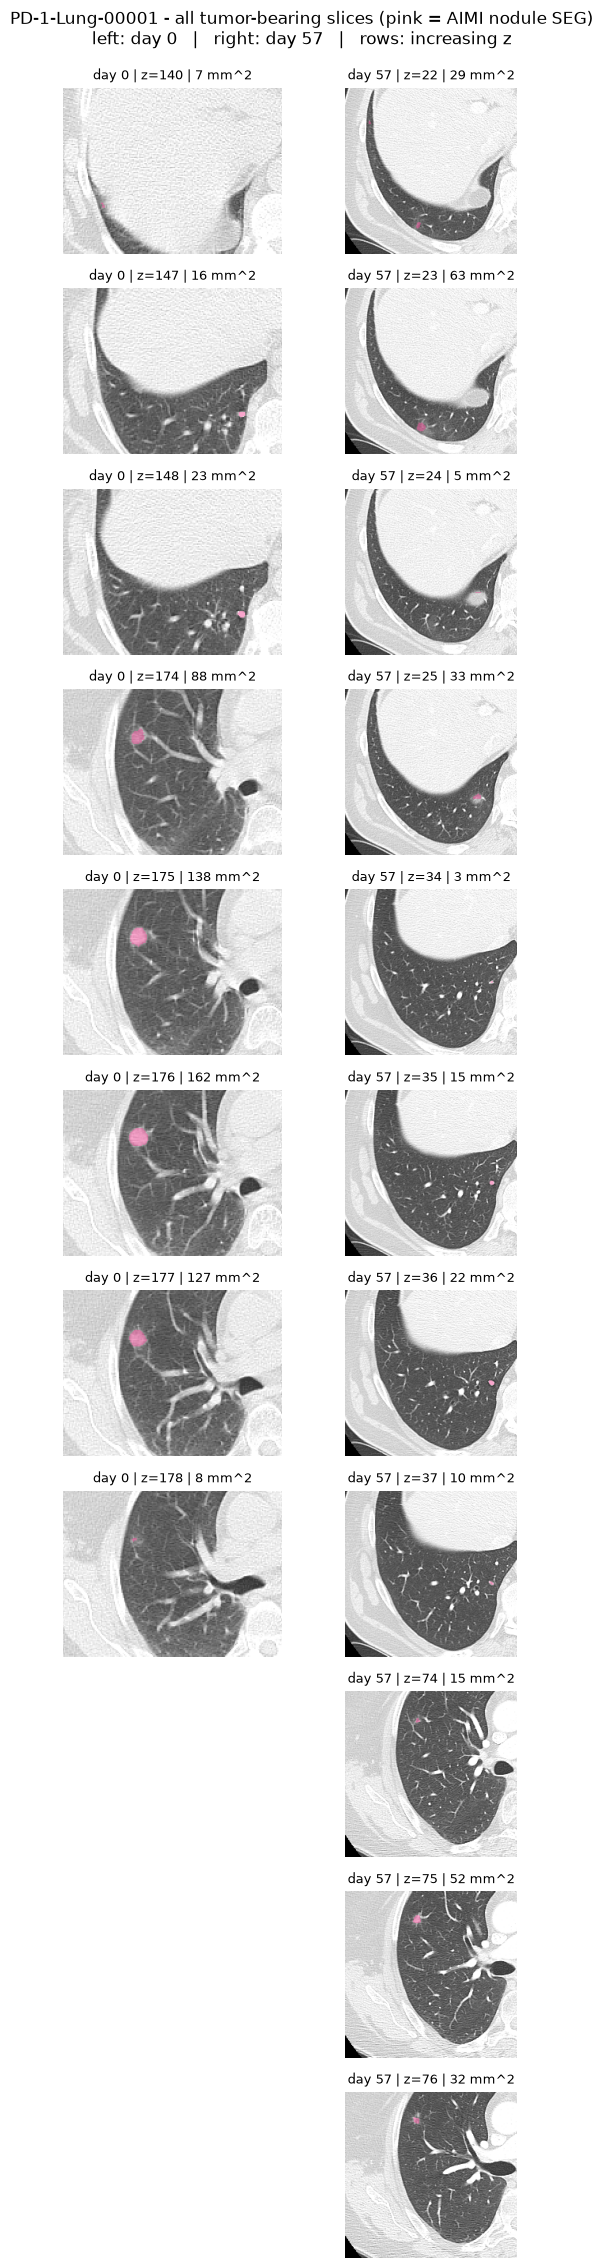

In [17]:
# Overlay of ALL tumor-bearing CT slices (pink = AIMI nodule SEG): day 0 (left) vs day 57 (right)
import numpy as np, matplotlib.pyplot as plt, SimpleITK as sitk

PINK = (0.95, 0.30, 0.60)
ordered = meta.sort_values("days_from_baseline")
day0, day57 = ordered["StudyDate"].iloc[0], ordered["StudyDate"].iloc[-1]
cols = [day0, day57]

def tumor_slices(day):
    m = gtv_masks[day]
    return [int(z) for z in np.where(m.reshape(m.shape[0], -1).any(axis=1))[0]]   # ascending z

def union_bbox(day, pad=30):
    m = gtv_masks[day]; zs = tumor_slices(day)
    ys, xs = np.where(m[zs].any(axis=0))
    return (max(0, ys.min()-pad), min(m.shape[1], ys.max()+pad),
            max(0, xs.min()-pad), min(m.shape[2], xs.max()+pad))

slices = {d: tumor_slices(d) for d in cols}
bboxes = {d: union_bbox(d) for d in cols}
nrows  = max(len(slices[d]) for d in cols)
for d in cols:
    dnum = int(meta.loc[meta.StudyDate == d, "days_from_baseline"].iloc[0])
    print(f"day {dnum} ({d}): {len(slices[d])} tumor slices at z = {slices[d]}")

lo, hi = -600 - 750, -600 + 750                       # lung window
fig, axes = plt.subplots(nrows, 2, figsize=(5.6, 2.1 * nrows))
axes = np.atleast_2d(axes)
for col, day in enumerate(cols):
    ctarr = sitk.GetArrayFromImage(ct_images[day]); mask = gtv_masks[day]
    y0, y1, x0, x1 = bboxes[day]
    sx, sy, sz = ct_images[day].GetSpacing()
    dnum = int(meta.loc[meta.StudyDate == day, "days_from_baseline"].iloc[0])
    for row in range(nrows):
        ax = axes[row, col]; ax.axis("off")
        if row >= len(slices[day]):
            continue
        z = slices[day][row]
        sl = ctarr[z, y0:y1, x0:x1].astype(float); m = mask[z, y0:y1, x0:x1]
        base = np.clip((sl - lo) / (hi - lo), 0, 1); rgb = np.stack([base]*3, axis=-1)
        for c in range(3):
            rgb[..., c][m] = 0.5 * rgb[..., c][m] + 0.5 * PINK[c]
        ax.imshow(rgb)
        ax.set_title(f"day {dnum} | z={z} | {m.sum()*sx*sy:.0f} mm^2", fontsize=9)

fig.suptitle(f"{PATIENT} - all tumor-bearing slices (pink = AIMI nodule SEG)\n"
             f"left: day 0   |   right: day 57   |   rows: increasing z", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.985])
fig.savefig("tumor_slices_grid.png", dpi=95, bbox_inches="tight")
plt.show()

### 5c. Interactive viewer (day 57) — run live in Jupyter

`ipywidgets` controls only respond inside a running Jupyter kernel (they do not render in a static
GitHub/nbviewer view). Run this cell in Jupyter to scroll through every z-slice of the day-57 scan,
switch CT window, and toggle the tumor (GTV) overlay in pink. For a zero-setup option, the IDC OHIF
web viewer shows the same study with the segmentation overlay:
`client.get_viewer_URL(studyInstanceUID=...)`.

In [19]:
# Interactive day-57 viewer: scroll z, toggle tumor (pink). Run in a live Jupyter kernel.
from ipywidgets import interact, IntSlider, FloatSlider, Checkbox, Dropdown
import numpy as np, matplotlib.pyplot as plt, SimpleITK as sitk

VIEW_DAY = "20081206"                      # day 57; change to "20081010" for baseline
_ct   = sitk.GetArrayFromImage(ct_images[VIEW_DAY])
_mask = gtv_masks[VIEW_DAY]
_PINK = (0.96, 0.28, 0.60)
_WIN  = {"lung (-600/1500)": (-600, 1500), "mediastinum (40/400)": (40, 400)}
_tz   = np.where(_mask.reshape(_mask.shape[0], -1).any(axis=1))[0]
_z0   = int(_tz.min()) if len(_tz) else _ct.shape[0] // 2

def view_day57(z, window, show_tumor, alpha):
    wl, ww = _WIN[window]; lo, hi = wl - ww / 2, wl + ww / 2
    base = np.clip((_ct[z].astype(float) - lo) / (hi - lo), 0, 1)
    rgb = np.stack([base] * 3, axis=-1)
    npix = int(_mask[z].sum())
    if show_tumor and npix:
        m = _mask[z]
        for c in range(3):
            rgb[..., c][m] = (1 - alpha) * rgb[..., c][m] + alpha * _PINK[c]
    tag = f"TUMOR ({npix} px)" if npix else "no tumor on this slice"
    plt.figure(figsize=(7, 7)); plt.imshow(rgb); plt.axis("off")
    plt.title(f"day 57 (2008-12-06)  |  z = {z} / {_ct.shape[0]-1}  |  {tag}")
    plt.show()

interact(
    view_day57,
    z=IntSlider(min=0, max=_ct.shape[0]-1, value=_z0, description="z"),
    window=Dropdown(options=list(_WIN), value="lung (-600/1500)", description="window"),
    show_tumor=Checkbox(value=True, description="tumor (pink)"),
    alpha=FloatSlider(min=0.2, max=0.9, step=0.1, value=0.5, description="alpha"),
);

interactive(children=(IntSlider(value=22, description='z', max=126), Dropdown(description='window', options=('…

## 6. Growth metrics

For consecutive timepoints (t0 → t1) with volumes V0, V1 over Δt days:

- **Absolute / relative change:** `V1 − V0`, `(V1 − V0)/V0`
- **Specific growth rate (SGR):** `ln(V1/V0) / Δt`  (per day)
- **Volume doubling time (VDT):** `Δt · ln(2) / ln(V1/V0)` — positive = growing, **negative = shrinking
  (treatment response)**

In [21]:
rows = []
for i in range(1, len(meta)):
    v0, v1 = meta.loc[i-1, "GTV_mL"], meta.loc[i, "GTV_mL"]
    dt = meta.loc[i, "days_from_baseline"] - meta.loc[i-1, "days_from_baseline"]
    sgr = math.log(v1/v0)/dt
    vdt = dt*math.log(2)/math.log(v1/v0)
    rows.append({
        "interval":     f"{meta.loc[i-1,'StudyDate']} -> {meta.loc[i,'StudyDate']}",
        "days":         dt,
        "V0_mL":        v0, "V1_mL": v1,
        "abs_change_mL": round(v1-v0, 3),
        "rel_change_%":  round((v1-v0)/v0*100, 1),
        "SGR_%per_day":  round(sgr*100, 3),
        "VDT_days":      round(vdt, 1),
    })
growth = pd.DataFrame(rows)
print(growth.to_string(index=False))

g = growth.iloc[0]
trend = "shrinking (treatment response)" if g["rel_change_%"] < 0 else "growing"
pr_vol = (1 - 0.7**3) * 100   # RECIST 1.1 PR = -30% diameter ~ -66% volume
status = ("meets partial-response threshold" if -g["rel_change_%"] >= pr_vol
          else "approaching but below partial-response threshold")
print(f"\nGTV is {trend}: {g['rel_change_%']:+.1f}% over {g['days']} days (VDT {g['VDT_days']:.0f} d).")
print(f"RECIST 1.1 partial response ~ -30% diameter ~ -{pr_vol:.0f}% volume; this scan {status}.")

growth.to_csv("growth_metrics.csv", index=False)
meta.to_csv("timepoint_records.csv", index=False)
print("\nSaved growth_metrics.csv and timepoint_records.csv")

            interval  days  V0_mL  V1_mL  abs_change_mL  rel_change_%  SGR_%per_day  VDT_days
20081010 -> 20081206    57  1.859  0.698         -1.161         -62.5        -1.719     -40.3

GTV is shrinking (treatment response): -62.5% over 57 days (VDT -40 d).
RECIST 1.1 partial response ~ -30% diameter ~ -66% volume; this scan approaching but below partial-response threshold.

Saved growth_metrics.csv and timepoint_records.csv


## 7. Visualize analytics

GTV at the two timepoints (day 0 vs day 57) as a bar chart, annotated with the percentage decline
computed in Section 6.

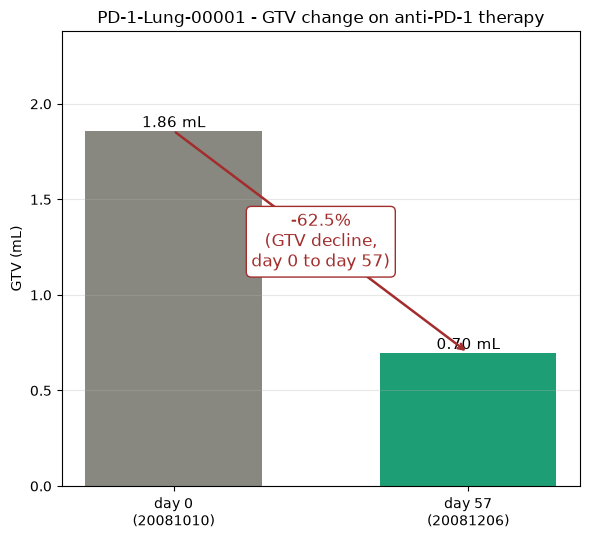

In [23]:
# GTV bar chart: day 0 vs day 57, annotated with the % decline from Section 6
import matplotlib.pyplot as plt

ordered = meta.sort_values("days_from_baseline")
v0 = float(ordered["GTV_mL"].iloc[0]); v1 = float(ordered["GTV_mL"].iloc[-1])
pct = float(growth.iloc[0]["rel_change_%"])           # computed in Section 6 (growth metrics)
labels = [f"day {int(ordered['days_from_baseline'].iloc[0])}\n({ordered['StudyDate'].iloc[0]})",
          f"day {int(ordered['days_from_baseline'].iloc[-1])}\n({ordered['StudyDate'].iloc[-1]})"]

fig, ax = plt.subplots(figsize=(6, 5.5))
bars = ax.bar(labels, [v0, v1], width=0.6, color=["#888780", "#1D9E75"])
for b, v in zip(bars, [v0, v1]):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:.2f} mL", ha="center", va="bottom", fontsize=11)
ax.set_ylabel("GTV (mL)"); ax.set_ylim(0, v0 * 1.28)
ax.set_title(f"{PATIENT} - GTV change on anti-PD-1 therapy")
ax.annotate("", xy=(1, v1), xytext=(0, v0),
            arrowprops=dict(arrowstyle="->", color="#A32D2D", lw=1.8))
ax.text(0.5, (v0 + v1)/2, f"{pct:+.1f}%\n(GTV decline,\nday 0 to day 57)", ha="center", va="center",
        fontsize=12, color="#A32D2D",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#A32D2D"))
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig("gtv_bar_day0_day57.png", dpi=120, bbox_inches="tight")
plt.show()

## 8. Interpretation and recommended monitoring

**Result.** Over the ~2-month (57days) window, this patient's tumor volume falls sharply — a volumetric
treatment response at **-62.5%** to anti-PD-1 immunotherapy (negative VDT at -40 days). According to the literature [7], this treatment showed **less than a partial-response threshold**.

**Caveat.** Only had two timepoints available for this task. Therefore, except for the absolute and relative change of GTV, SGR and VDT in Section 6 assumed linearity in the tumor volume reduction.

**Recommended monitoring for immune-related adverse events (irAEs).** Anti-PD-1 therapy can trigger
autoimmune-like toxicity in essentially any organ; most events are mild and reversible, but some
(notably myocarditis) are rare and potentially fatal, so guideline-based baseline and periodic
laboratory monitoring is recommended [1, 2, 3]. For this patient, tests to confirm these adverse effects
are *not* elevated include:

- **Thyroid / pituitary (endocrinopathy, hypophysitis — among the most common irAEs):** TSH and free T4,
  plus morning cortisol and ACTH if hypophysitis or adrenal insufficiency is suspected [1, 2].
- **Liver (immune hepatitis):** AST, ALT, and total bilirubin (liver function tests) [1, 2].
- **Kidney (immune nephritis):** serum creatinine [1, 2].
- **Heart (myocarditis — rare but high case-fatality):** troponin with ECG; consider CK and
  BNP/NT-proBNP [1, 4].
- **Pancreas / metabolic (new-onset type 1 diabetes):** fasting glucose (± HbA1c) [1].
- **Blood (immune cytopenias):** complete blood count with differential [1].
- **Inflammation / colitis:** C-reactive protein (CRP), and — if diarrhea develops — fecal calprotectin and
  stool studies [1, 2].
- **Lung (pneumonitis), especially relevant in thoracic disease:** assessed mainly by symptoms, pulse
  oximetry, and chest imaging rather than a single blood biomarker [1, 2].

*Of course, just an ignorant scientist spitting medical words that might be beneficial.* The chemotherapy combined with further immunotherapy would have to precede these tests to reach the therapeutic goal.

**Citations — irAE monitoring**
1. Schneider, B. J., et al. (2021). [Management of Immune-Related Adverse Events in Patients Treated With Immune Checkpoint Inhibitor Therapy: ASCO Guideline Update](https://consensus.app/papers/details/97795baca8f85db88c0030bd84c18606/?utm_source=claude_code). *Journal of Clinical Oncology*, 39(36).
2. Brahmer, J. R., et al. (2018). [Management of Immune-Related Adverse Events: ASCO Clinical Practice Guideline](https://consensus.app/papers/details/e982f9a92980534db8e9d887d62bd5c6/?utm_source=claude_code). *Journal of Clinical Oncology*, 36(17).
3. Martins, F., et al. (2019). [Adverse effects of immune-checkpoint inhibitors: epidemiology, management and surveillance](https://consensus.app/papers/details/f3c4b5cbeb6a55859497f4858bf4c9a0/?utm_source=claude_code). *Nature Reviews Clinical Oncology*, 16.
4. Ramos-Casals, M., et al. (2020). [Immune-related adverse events of checkpoint inhibitors](https://consensus.app/papers/details/d26d1c623b045a6da5b2d4a944d7c484/?utm_source=claude_code). *Nature Reviews Disease Primers*, 6.
5. Johnson, D. B., et al. (2022). [Immune-checkpoint inhibitors: long-term implications of toxicity](https://consensus.app/papers/details/1a83971f6f8e5009b309bf24da112a5b/?utm_source=claude_code). *Nature Reviews Clinical Oncology*, 19.

**Citations — data & methods**
- *Imaging collection (anti-PD-1 immunotherapy lung):* the `anti_pd_1_lung` collection in The Cancer
  Imaging Archive (TCIA). Use `client.citations_from_selection(collection_id="anti_pd_1_lung")` for the
  exact data-citation DOI at your data version.
- *AI tumor/nodule segmentations:* BAMF Health / IDC AIMI annotations — Murugesan, G. K., et al. (2023).
  *AI-generated annotations for several IDC collections (BAMF)* [Dataset]. Zenodo.
  https://doi.org/10.5281/zenodo.8345959
- *The Cancer Imaging Archive:* Clark, K., et al. (2013). *Journal of Digital Imaging*, 26(6), 1045-1057.
  https://doi.org/10.1007/s10278-013-9622-7
- *Imaging Data Commons:* Fedorov, A., et al. (2023). *RadioGraphics*, 43(12), e230180.
  https://doi.org/10.1148/rg.230180
- *Volume doubling time as a lung-cancer growth/prognosis metric:* Jiang, B., et al. (2024). Lung cancer
  volume doubling time by CT: a systematic review and meta-analysis. *European Journal of Cancer*.
  https://doi.org/10.1016/j.ejca.2024.114120

## 9. Planned next study

As a non-medical professional, I had trouble distinguishing the tumor, so validation of the AI model performance was limited. Therefore, the next notebook will track GTV more precisely by combining **metabolic** and **anatomical** information
and by adding **human** expert input:

- **Baseline (day 0) — metabolic GTV from PET/CT.** Compute GTV from the **FDG-PET/CT** using the
  *FDG-avid tumor* AI segmentation (`AIMI lung and FDG tumor AI segmentation`, model `BAMF-Lung-FDG-PET-CT`),
  i.e. a metabolic tumor volume, instead of the CT-only nodule mask.
- **Follow-up (day 57) — consensus GTV with human input.** Compute GTV from the **convergence of three
  layers**: the AIMI AI nodule segmentation plus the two radiologist-corrected segmentations
  (`radiologist 1` and `radiologist 2`) to reduce single-method bias.
- **Goal.** A more robust day 0 → day 57 comparison pairing a metabolically assessed baseline with a human-validated
  follow-up volume.